In [ ]:
from PIL import Image
import os

SRC = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\raw\brain_tumors"  
DST = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed"  
os.makedirs(DST, exist_ok=True)

TARGET_SIZE = (256, 256)

for cls in os.listdir(SRC):
    folder = os.path.join(SRC, cls)
    if os.path.isdir(folder):
        count = 0
        for fn in os.listdir(folder):
            if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(folder, fn)
                try:
                    img = Image.open(path).convert('L')  
                    img = img.resize(TARGET_SIZE)        
                    outname = f"{cls.lower()}_{os.path.splitext(fn)[0]}.png"
                    img.save(os.path.join(DST, outname))
                    count += 1
                except Exception as e:
                    print(f"Error processing {fn}: {e}")
        print(f"Processed {count} images from {cls}")


Processed 15 images from glioma
Processed 15 images from meningioma
Processed 15 images from notumor
Processed 15 images from pituitary


Found 60 processed images.
Showing first few samples...


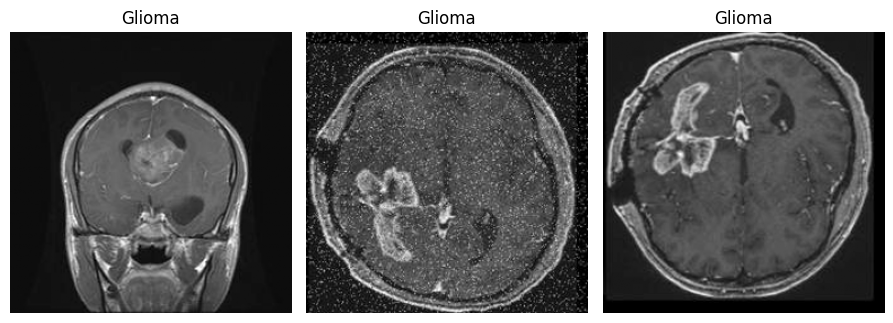

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed"

image_files = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"Found {len(image_files)} processed images.")
print("Showing first few samples...")

plt.figure(figsize=(12, 8))
for i, img_name in enumerate(image_files[:3]):
    img_path = os.path.join(IMG_DIR, img_name)
    img = Image.open(img_path)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(img_name.split("_")[0].capitalize())
    plt.axis('off')

plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import os, glob, re

IMG_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed"
EHR_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\ehr_notes_processed\cleaned_ehr.csv"
LOOKUP_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\icd_lookup.csv"
OUT_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\mapping.csv"

lookup = pd.read_csv(LOOKUP_PATH)

def get_icd_code(diagnosis):
    diagnosis = str(diagnosis).lower().strip().replace("_", "").replace("-", "")
    for _, row in lookup.iterrows():
        key = str(row['condition_keyword']).lower().strip().replace("_", "").replace("-", "")
        if key in diagnosis:
            return row['icd10_code']
    return "UNKNOWN"

images = sorted(glob.glob(os.path.join(IMG_PATH, "*.png")))

rows = []
for i, img in enumerate(images):
    diagnosis = os.path.basename(img).split("_")[0].lower().strip()
    icd_code = get_icd_code(diagnosis)
    rows.append({
        "file_id": f"{i+1:04d}",
        "image_path": img,
        "ehr_path": EHR_PATH,
        "diagnosis": diagnosis,
        "icd10_code": icd_code
    })

mapping_df = pd.DataFrame(rows)
mapping_df.to_csv(OUT_PATH, index=False)
print(" mapping.csv regenerated successfully!")
print(mapping_df.head())


 mapping.csv regenerated successfully!
  file_id                                         image_path  \
0    0001  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...   
1    0002  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...   
2    0003  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...   
3    0004  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...   
4    0005  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...   

                                            ehr_path diagnosis icd10_code  
0  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...    glioma      C71.9  
1  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...    glioma      C71.9  
2  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...    glioma      C71.9  
3  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...    glioma      C71.9  
4  C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...    glioma      C71.9  


In [7]:
import pandas as pd
import os

EHR_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\raw\ehr_dataset.csv"

df = pd.read_csv(EHR_PATH)
print(" Data loaded successfully!\n")
print(df.info())
print("\n Preview:")
display(df.head())


 Data loaded successfully!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             20000 non-null  object 
 1   Age                    20000 non-null  int64  
 2   Gender                 20000 non-null  object 
 3   Tumor_Size(cm)         20000 non-null  float64
 4   Tumor_Type             20000 non-null  object 
 5   Biopsy_Result          20000 non-null  object 
 6   Treatment              20000 non-null  object 
 7   Response_to_Treatment  20000 non-null  object 
 8   Survival_Status        20000 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.4+ MB
None

 Preview:


,Patient_ID,Age,Gender,Tumor_Size(cm),Tumor_Type,Biopsy_Result,Treatment,Response_to_Treatment,Survival_Status
0,c044501a-43ca-4a0c-8b8b-991439ba1b6a,52,Female,5.08,Benign,Positive,Surgery,No Response,Survived
1,b8900c4c-1232-4084-9432-5d02eba74d20,32,Female,0.80,Benign,Negative,Surgery,Complete Response,Survived
2,3004e2bc-8037-49cb-a542-d5612b73beab,70,Female,9.56,Benign,Positive,Radiation Therapy,Complete Response,Deceased
3,1df86af7-6745-4dea-b127-cbc9915079fc,21,Female,3.07,Malignant,Negative,Surgery,Partial Response,Survived
4,128e00c3-72e3-4031-a7f4-1165d7199cce,62,Male,7.17,Malignant,Positive,Radiation Therapy,Complete Response,Deceased


In [8]:

df = df.dropna().drop_duplicates()

df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.lower().str.strip()

print(" Cleaned EHR dataset — total records:", len(df))


 Cleaned EHR dataset — total records: 20000


In [9]:
CLEAN_EHR_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\ehr_notes_processed\cleaned_ehr.csv"
os.makedirs(os.path.dirname(CLEAN_EHR_PATH), exist_ok=True)
df.to_csv(CLEAN_EHR_PATH, index=False)
print("Cleaned EHR file saved to:", CLEAN_EHR_PATH)


Cleaned EHR file saved to: C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\ehr_notes_processed\cleaned_ehr.csv


In [10]:
import pandas as pd

EHR_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\ehr_notes_processed\cleaned_ehr.csv"
MAPPING_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\mapping.csv"

ehr_df = pd.read_csv(EHR_PATH)
map_df = pd.read_csv(MAPPING_PATH)

print("Loaded EHR:", ehr_df.shape)
print("Loaded Mapping:", map_df.shape)


Loaded EHR: (20000, 9)
Loaded Mapping: (60, 5)


In [14]:
import random

tumor_classes = ['glioma', 'meningioma', 'pituitary', 'notumor']
ehr_df['tumor_type_normalized'] = [random.choice(tumor_classes) for _ in range(len(ehr_df))]

ehr_df['tumor_type_normalized'].value_counts()


tumor_type_normalized
notumor       5062
meningioma    5020
glioma        4972
pituitary     4946
Name: count, dtype: int64

In [19]:
ehr_subset = ehr_df.sample(60).copy()
ehr_subset['tumor_type_normalized'] = ['glioma']*15 + ['meningioma']*15 + ['pituitary']*15 + ['notumor']*15

linked_df = pd.merge(
    map_df,
    ehr_subset,
    left_on='diagnosis',
    right_on='tumor_type_normalized',
    how='inner'
)

print(" Linked records:", linked_df.shape)
linked_df[['file_id','diagnosis','age','gender','treatment','survival_status']].head()


 Linked records: (900, 16)


,file_id,diagnosis,age,gender,treatment,survival_status
0,1,glioma,61,male,chemotherapy,survived
1,1,glioma,45,male,surgery,survived
2,1,glioma,47,female,radiation therapy,survived
3,1,glioma,70,female,chemotherapy,deceased
4,1,glioma,23,female,surgery,deceased


In [20]:
LINKED_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\linked_brain_ehr.csv"
linked_df.to_csv(LINKED_PATH, index=False)
print(" Linked dataset saved to:", LINKED_PATH)

 Linked dataset saved to: C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\linked_brain_ehr.csv


In [21]:
import pandas as pd

linked_df = pd.read_csv(r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\linked_brain_ehr.csv")

print("Total records:", len(linked_df))
print("\nICD-10 code distribution:")
print(linked_df['icd10_code'].value_counts())
print("\nSurvival status breakdown:")
print(linked_df['survival_status'].value_counts())


Total records: 900

ICD-10 code distribution:
icd10_code
C71.9    225
D32.9    225
Z00.0    225
D35.2    225
Name: count, dtype: int64

Survival status breakdown:
survival_status
survived    465
deceased    435
Name: count, dtype: int64


In [8]:
import pandas as pd
import os, re

MAPPING_PATH = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\linked_brain_ehr.csv"

df = pd.read_csv(MAPPING_PATH)

print("=== BASIC INFO ===")
print(f"Total Records: {len(df)}")
print(f"Unique Diagnoses: {df['diagnosis'].nunique()}")
print(f"ICD Codes: {df['icd10_code'].unique().tolist()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print("="*60)

missing_images = df[~df['image_path'].apply(os.path.exists)]
print(f"Missing image files: {len(missing_images)}")
if not missing_images.empty:
    print(missing_images[['file_id', 'image_path']].head())

missing_ehr = df[~df['ehr_path'].apply(os.path.exists)]
print(f"Missing EHR files: {len(missing_ehr)}")
if not missing_ehr.empty:
    print(missing_ehr[['file_id', 'ehr_path']].head())

icd_pattern = re.compile(r'^[A-Z][0-9]{2}(\.[A-Z0-9]{1,4})?$')
bad_icd = df[~df['icd10_code'].apply(lambda x: bool(icd_pattern.match(str(x))))]
print(f"Invalid ICD codes: {len(bad_icd)}")
if not bad_icd.empty:
    print(bad_icd[['file_id', 'diagnosis', 'icd10_code']].head())

dupes = df[df.duplicated(subset=['patient_id', 'diagnosis'], keep=False)]
dupes = df.drop_duplicates()
print("Patient-level duplicates:", len(dupes))

empty_text = df[df['combined_text'].astype(str).str.strip() == ""]
print(f"Empty combined_text fields: {len(empty_text)}")

print("\nUnique values per key field:")
print("Diagnosis:", df['diagnosis'].unique())
print("Survival Status:", df['survival_status'].unique())
print("Response to Treatment:", df['response_to_treatment'].unique())

print("\nIntegrity & sanity checks completed.")


=== BASIC INFO ===
Total Records: 900
Unique Diagnoses: 4
ICD Codes: ['C71.9', 'D32.9', 'Z00.0', 'D35.2']

Missing Values:
file_id                  0
image_path               0
ehr_path                 0
diagnosis                0
icd10_code               0
patient_id               0
age                      0
gender                   0
tumor_size(cm)           0
tumor_type               0
biopsy_result            0
treatment                0
response_to_treatment    0
survival_status          0
combined_text            0
tumor_type_normalized    0
dtype: int64
Missing image files: 0
Missing EHR files: 0
Invalid ICD codes: 0
Patient-level duplicates: 900
Empty combined_text fields: 0

Unique values per key field:
Diagnosis: ['glioma' 'meningioma' 'notumor' 'pituitary']
Survival Status: ['survived' 'deceased']
Response to Treatment: ['partial response' 'no response' 'complete response']

Integrity & sanity checks completed.
